In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_BASE_URL"]=os.getenv("BEDROCK_MANTLE_BASE_URL")
os.environ["OPENAI_API_KEY"]=os.getenv("BEDROCK_MANTLE_API_KEY")

In [2]:
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="moonshotai.kimi-k2-thinking",
    base_url=os.environ["OPENAI_BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
    temperature=0,
)

# Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behavior with logging, analytics, and debugging.
- Transforming prompts, tool selection, and output formatting.
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection.

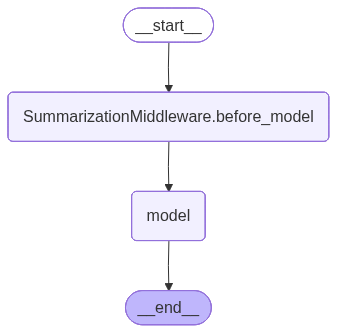

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

# Creating agent
agent = create_agent(
    model=model,
    tools=[],
    checkpointer=InMemorySaver(),
    middleware=[SummarizationMiddleware(
        model=model,
        trigger=("messages",10),
        keep=("messages",4)
    )]
)

agent

In [8]:
config={"configurable":{"thread_id":"test-1"}}

In [10]:
questions = [
    "What is 2 + 2?",
    "What is 10*5?",
    "What is 100/4?",
    "What is 15-7?",
    "What is 3*3?",
    "What is 4*4?"
]

for q in questions:
    response = agent.invoke({"messages":[HumanMessage(content=q)]}, config)
    print(f"Message: {response}")
    print(f"Message: {len(response['messages'])}")

Message: {'messages': [HumanMessage(content='What is 2 + 2?', additional_kwargs={}, response_metadata={}, id='316d4259-4495-4421-a8cc-0e775d5639cd'), AIMessage(content=' 2 + 2 = 4', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 36, 'total_tokens': 95, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 16}}, 'model_provider': 'openai', 'model_name': 'moonshotai.kimi-k2-thinking', 'system_fingerprint': None, 'id': 'chatcmpl-4c7395f8-730c-4f78-b911-ab47ef7c742c', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f06df-bc77-7a43-81e1-45c2c191828d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 59, 'total_tokens': 95, 'input_token_details': {'audio': 0, 'cache_read': 16}, 'output_token_details': {}}), HumanMessage(content='What is 2 + 2?', additional_kwargs={}, response_metadata={}, id='742fcc59-3

### Summerization (Token Size)